# Way 1: From Scratch

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [32]:
# Load Data
df = pd.read_csv('student_regression.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


  Alpha   | Train R²  | Test R²   | Diagnosis
  0       | 0.9439    | 0.9181    | Plain Linear Regression
  0.1     | 0.9439    | 0.9182    | Good ✅
  1       | 0.9439    | 0.9187    | Good ✅
  10      | 0.9437    | 0.9222    | Good ✅
  100     | 0.9394    | 0.9265    | Good ✅
  1000    | 0.9019    | 0.8942    | Good ✅


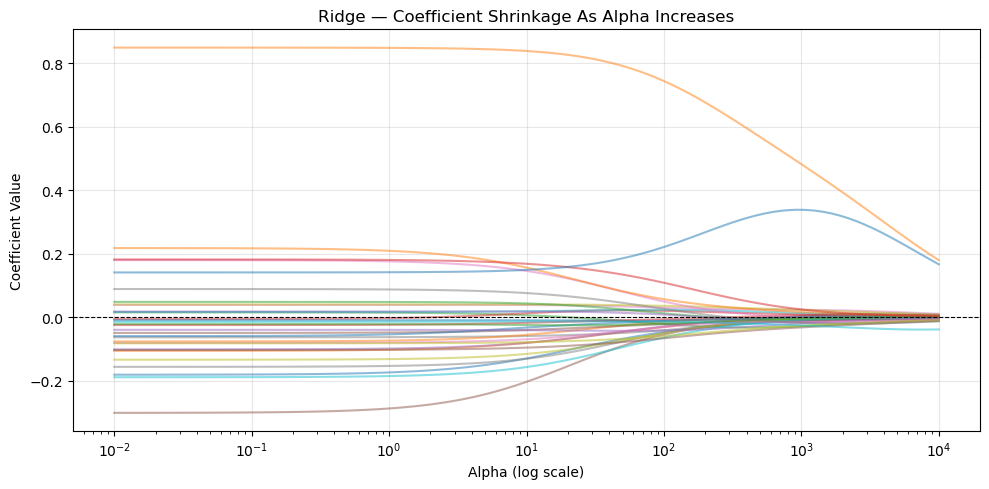

In [33]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include = 'object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Features and target
X = df_encoded.drop(columns = ['G3']).values
y = df_encoded['G3'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Add bias column  manually
n_train = X_train.shape[0]
X_train_b = np.hstack([np.ones((n_train, 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Ridge from scratch - closed form solution
def ridge_from_scratch(X, y, alpha):
    n_features = X.shape[1]

    # Identity matrix - same size as XᵀX
    I = np.eye(n_features)

    # Do not penalize the intercept (first parameter)
    I[0,0] = 0

    # Ridge formula: θ = (XᵀX + αI)⁻¹ Xᵀy
    theta = np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y
    return theta

# Compare different alpha values
print("=" * 65)
print(f"  Alpha   | Train R²  | Test R²   | Diagnosis")
print("=" * 65)

alphas = [0, 0.1, 1, 10, 100, 1000]
for alpha in alphas:
    theta = ridge_from_scratch(X_train_b, y_train, alpha)

    # Predict 
    y_train_pred = X_train_b @ theta
    y_test_pred = X_test_b @ theta


    tr2 = r2_score(y_train, y_train_pred)
    te2 = r2_score(y_test, y_test_pred)

    gap = tr2 - te2

    if alpha == 0:
        diagnosis = 'Plain Linear Regression'
    elif gap > 0.15:
        diagnosis = 'Overfitting'
    elif tr2 < 0.5:
        diagnosis = 'Too much regularization ⚠️'
    else:
        diagnosis = 'Good ✅'

    print(f"  {alpha:<7} | {tr2:.4f}    | {te2:.4f}    | {diagnosis}")

print("=" * 65)

# Visualize coefficient shrinkage
alphas_plot = np.logspace(-2,4,100) # 100 alpha values from 0.01 to 10000
coefs = []

for alpha in alphas_plot:
    theta = ridge_from_scratch(X_train_b, y_train, alpha)
    coefs.append(theta[1:]) # Exclude intercept

coefs = np.array(coefs)

plt.figure(figsize = (10,5))
for i in range(coefs.shape[1]):
    plt.plot(alphas_plot, coefs[:,i], alpha = 0.5)

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge — Coefficient Shrinkage As Alpha Increases')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Way 2: Using Scikit-Learn

In [34]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [35]:
# Load and prepare data
df = pd.read_csv('student_regression.csv')

# Encode all text columns into numbers that sklearn can process
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include = 'object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns = ['G3']) # all features except target
y = df_encoded['G3'] # final grade - what we predict

feature_names = X.columns.to_list()  # save for coefficient analysis

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# ____ STEP 1: Find the best alpha automatically using RidgeCV
# RidgeCV = Ridge with built-in Cross Validation
# It trains Ridge at every alpha you provide and picks the best one
# This replaces the manual loop - industry standard approach

alphas_to_try = np.logspace(-3, 4, 100)

# logspace generates 100 values evenly spaced on a log scale from 1e-3 to 1e4
# log scale because alpha effect is multiplicative, not additive
# e.g. difference between 0.001 and 0.01 matters as much as 1 and 10

ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    # StandardScaler is mandatory before Ridge - regularization penalizes large 
    # coefficients but the coefficient size depends on the feature scale
    # scaling puts all features on equal footing first

    ('ridge_cv', RidgeCV(
        alphas = alphas_to_try,
        # cv = 5 means 5-fold cross-validation - data split into 5 parts,
        # model trained 5 times
        # each time one part is test, four parts are train
        # best alpha = one that performs best across all 5 folds
        cv = 5,
        scoring = 'r2' # optimize for R-squared - can change to neg_mse
    ))
])

ridge_cv.fit(X_train, y_train)

# retrieve the alpha RidgeCV selected as best
best_alpha = ridge_cv.named_steps['ridge_cv'].alpha_
print(f"Best alpha found by RidgeCV: {best_alpha:.4f}")

Best alpha found by RidgeCV: 1.2915


In [36]:
# ____ STEP 2: Evaluate the auto-selected model
train_r2 = r2_score(y_train, ridge_cv.predict(X_train))
test_r2 = r2_score(y_test, ridge_cv.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test)))

print(f"\nRidge Performance (best alpha={best_alpha:.4f})")
print(f"  Train R²  : {train_r2:.4f}")
print(f"  Test R²   : {test_r2:.4f}")
print(f"  RMSE      : {rmse:.4f} grade points")
print(f"  Gap       : {train_r2 - test_r2:.4f}  ", "(< 0.05 is healthy, > 0.15 is overfitting)")


Ridge Performance (best alpha=1.2915)
  Train R²  : 0.9439
  Test R²   : 0.9178
  RMSE      : 0.8901 grade points
  Gap       : 0.0261   (< 0.05 is healthy, > 0.15 is overfitting)


In [37]:
# STEP 3: Predict actual student grades
y_pred = ridge_cv.predict(X_test)

# build a readable comparison table
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.round(1),
    'Error': (y_test.values - y_pred).round(2)
})

print("\nActual vs Predicted Grades (first 10 students):")
results.head(10)


Actual vs Predicted Grades (first 10 students):


,Actual,Predicted,Error
0,12,12.5,-0.49
1,18,18.2,-0.25
2,11,11.1,-0.11
3,9,9.5,-0.48
4,15,15.6,-0.63
5,9,6.8,2.24
6,14,14.4,-0.37
7,15,14.6,0.44
8,9,8.7,0.33
9,8,7.2,0.76


In [38]:
# ____STEP 4: Analyze which features Ridge considers most important
# Ridge never zeros out coefficients - all features kept
# but coeffiicients with larger absolute value matter more

ridge_coefs = ridge_cv.named_steps['ridge_cv'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_coefs
}).sort_values('Coefficient', key = abs, ascending = False)
# sort by avsolute value  - positive and negative both matter

print(f" Top 10 Most Important Features (Ridge):")
coef_df.head(10)

 Top 10 Most Important Features (Ridge):


,Feature,Coefficient
31,G2,2.630538
30,G1,0.517941
23,famrel,0.158405
29,absences,-0.125848
28,health,-0.110684
27,Walc,0.110569
25,goout,-0.109991
5,Pstatus,-0.096774
16,famsup,0.086368
21,internet,0.086322


In [39]:
print(f"\nFeatures with near-zero coefficient (< 0.01):")
near_zero = coef_df[abs(coef_df['Coefficient'] < 0.01)]
print(near_zero.to_string(index=False) if len(near_zero) > 0 else "  None — Ridge keeps all features")


Features with near-zero coefficient (< 0.01):
   Feature  Coefficient
  absences    -0.125848
    health    -0.110684
     goout    -0.109991
   Pstatus    -0.096774
      paid    -0.076407
   nursery    -0.074540
      Dalc    -0.072059
      Fedu    -0.069494
activities    -0.064453
    school    -0.059391
       sex    -0.055408
   famsize    -0.045116
  freetime    -0.043180
  guardian    -0.040063
 studytime    -0.021447
 schoolsup    -0.019661
    higher    -0.014699
    reason    -0.011619
  romantic    -0.010687
   address    -0.001258


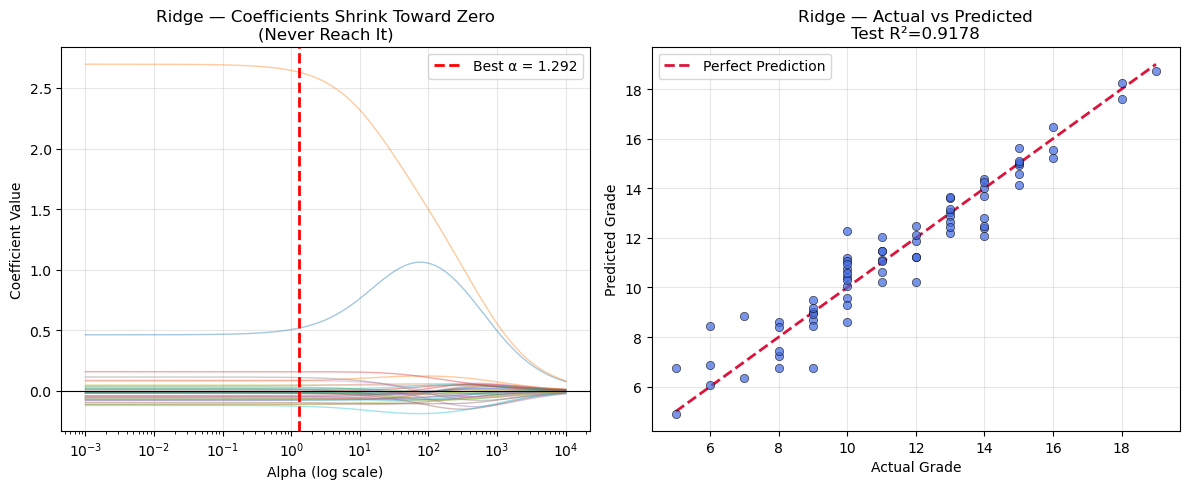

In [43]:
# ____ STEP 5:  Visualize coefficient shrinkage across alpha values ---
# shows how Ridge pushes coefficients toward zero as alpha increases 
# helps visually confirm regularization is working

coef_paths = []
alpha_range = np.logspace(-3, 4, 200)

for a in alpha_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=a))
    ])
    pipe.fit(X_train, y_train)
    coef_paths.append(pipe.named_steps['ridge'].coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(coef_paths.shape[1]):
    plt.plot(alpha_range, coef_paths[:, i], alpha=0.4, linewidth=1)
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=2,
            label=f'Best α = {best_alpha:.3f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge — Coefficients Shrink Toward Zero\n(Never Reach It)')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7,
            edgecolors='black', linewidths=0.5, zorder=5)
# perfect prediction line — points close to this = good model
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='crimson', linewidth=2, linestyle='--',
         label='Perfect Prediction')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title(f'Ridge — Actual vs Predicted\nTest R²={test_r2:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# why did we not just drop the whole column instead of just the value of the column?
# similarly why we store the values only instead of the whole column?
# did not we find the mean squared error using the actual y and the predicted y? then why did you do like that for rmse?
# what does key do in the sort_values method?
# what is ridge_cv? what does it do?
# why did you use ([y_test.min(), y_test.max()], [y_test.min(), y_test.max()] for drawing the line
# most importantly, I think I am not able to read the graph, how could I interpret the graph

# Lasso Regression

## Way 1: From Scratch

In [ ]:
# Lasso from scratch - coordinate descent
def soft_threshold(z,alpha):
    """
        The core operation of Lasso
        If |z| > alpha --> shrink by alhpa
        If |z| <= alpha --> return exactly 0
    """

    if z > alpha:
        return z - alpha
    elif z < -alpha:
        return z + alpha
    else:
        return 0.0  # ← this is how exact zeros happen

def lesso_coordiante_descent(X,y,alpha,max_iter=100,tol=1e-4):
    """
        Lasso via Coordinate Descent
        Optimizes one coefficient at a time - holding all others fixed
    """
    n,p = X.shape
    theta = np.zeros(p)  # start all coefficients at 0

    for iteration in range(max_iter):
        theta_old = theta.copy()

        # Cycles through every feature one at a time
        for j in range(p):
            # Residual without feature j's contribution
            residual = y - X @ theta + X[:, j]* theta[j]

            # Raw optimal coefficient for feature j
            z_j = X[:, j] @ residual / n

            # Apply soft thresholding - this is where zeros happen
            if j == 0:
                # Do not penalize the intercept
                theta[j] = z_j / (X[:, j] @ X[:, j] / n)
            else:
                theta[j] = soft_threshold(z_j, alpha) / (X[:, j] @ X[:, j] / n)

            # Check convergence - stop id coefficients barely changed 
            if np.max(np.abs(theta - theata_old)) < tol:
                print(f" Convergence at iteration {itearation + 1}")
                break
        return theta
            

# Run on student data
print("=" * 65)
print("LASSO FROM SCRATCH — Alpha Comparison")
print("=" * 65)

for alpha in [0.001, 0.01, 0.1, 1.0]:
    theta = lasso_coordinate_descent(X_train_b, y_train, alpha)

    y_train_pred = X_train_b @ theta
    y_test_pred = X_test_b @ theta

    tr2 = r2_score(y_train, y_train_pred)
    te2 = r2_score(y_test, y_test_pred)

    # Count how many coefficients became exactly zero
    n_zeros = np.sum(theta[1:] == 0)  # exclude intercept

    print(f"\nAlpha = {alpha}")
    print(f"  Train R²           : {tr2:.4f}")
    print(f"  Test R²            : {te2:.4f}")
    print(f"  Features eliminated: {n_zeros} out of {len(theta)-1}")
    

# Way 2: Proffessional (Scikit-Learn)

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
print("=" * 65)
print("LASSO — Professional")
print("=" * 65)
print(f"\n  Alpha   | Train R²  | Test R²   | Features Kept | Eliminated")
print("=" * 65)